In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [32]:
def display_with_mean(ts: np.array, data: np.array, title: str, y_label: str):
    t_min = np.min(ts)
    t_max = np.max(ts)

    plt.figure(dpi=100)
    plt.title(f"{title}")
    plt.xlabel(r"$t, ns$")
    plt.ylabel(f"{y_label}")
    plt.grid()
    plt.plot(ts, data, "-")
    plt.hlines(
        np.mean(data[1_000:]),
        1.1 * t_min,
        t_max,
        colors="red",
        linestyles="--",
        label=f"{np.mean(data[1_000:]):10f}",
    )
    plt.legend(loc="best")
    plt.show()

    return np.mean(data[1_000:])

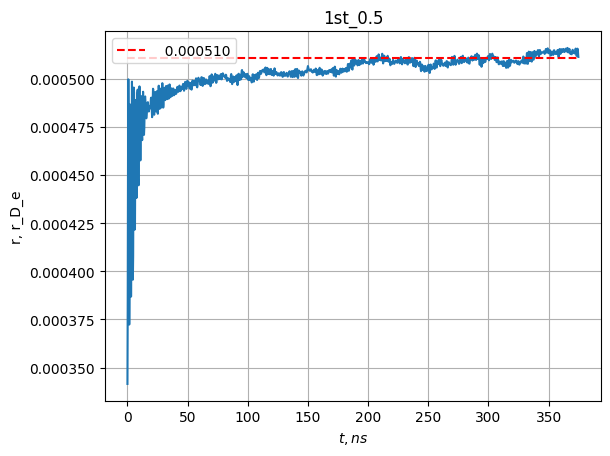

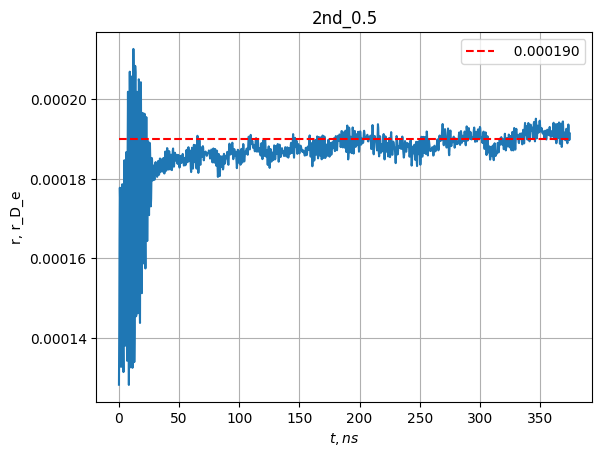

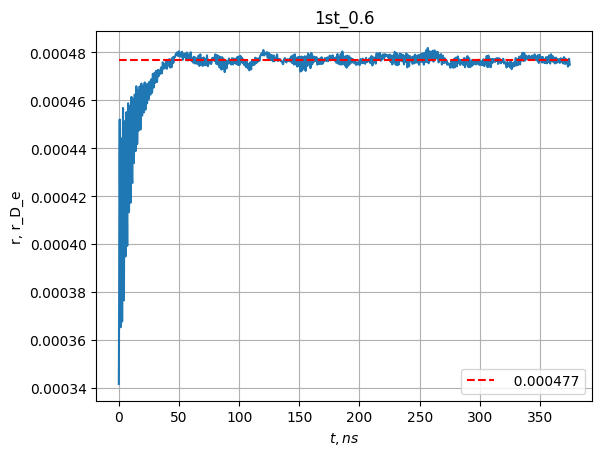

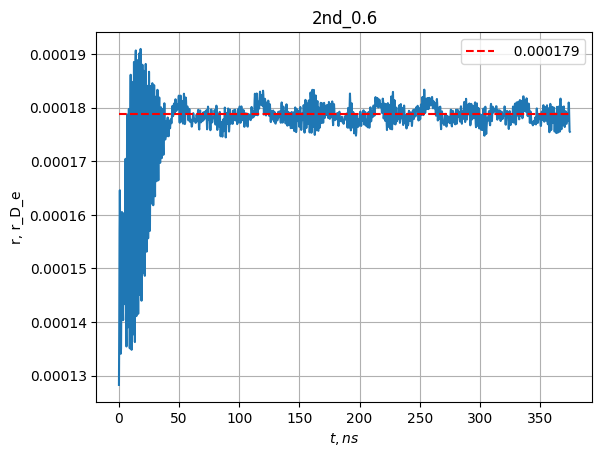

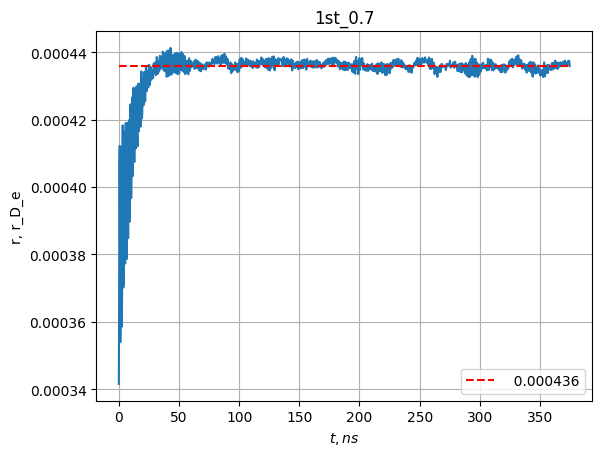

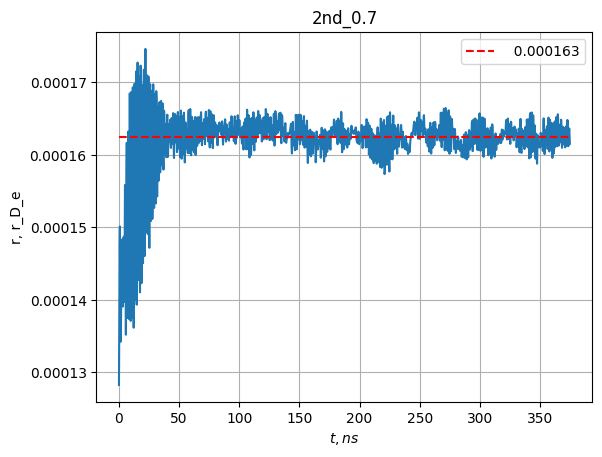

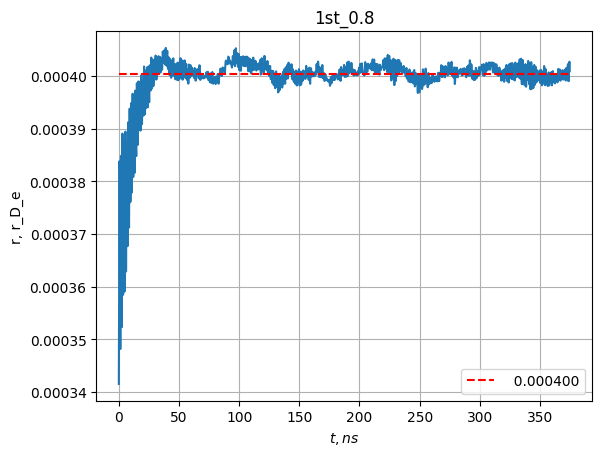

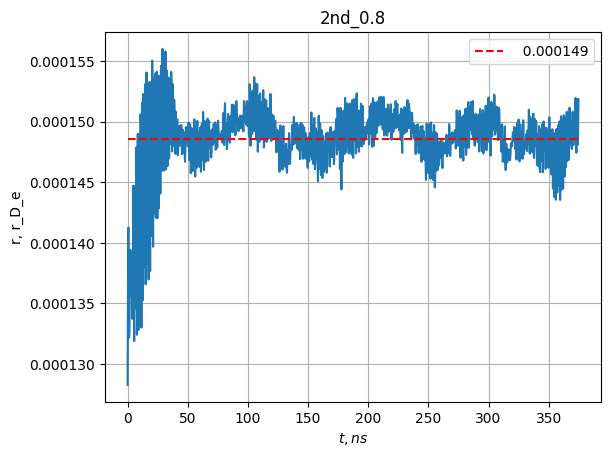

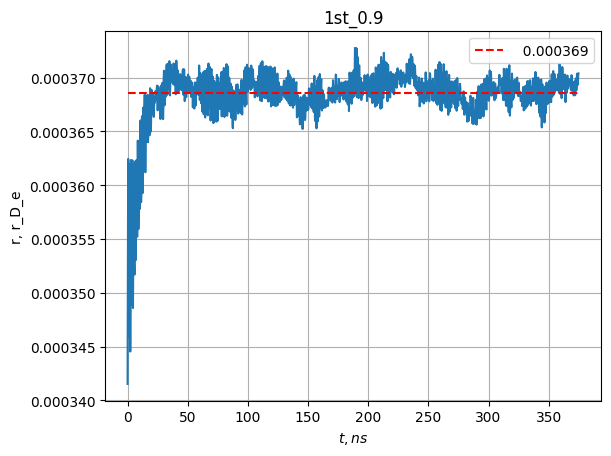

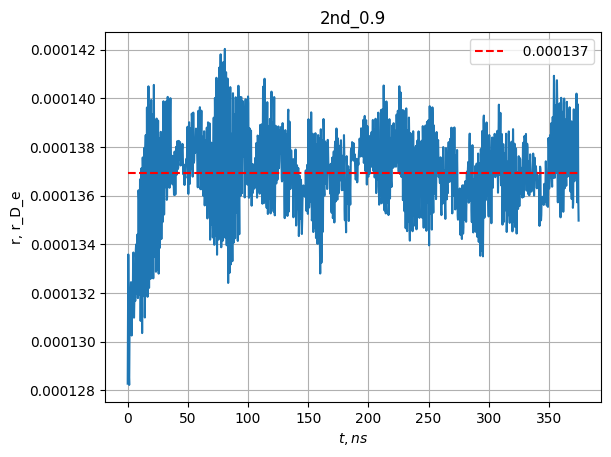

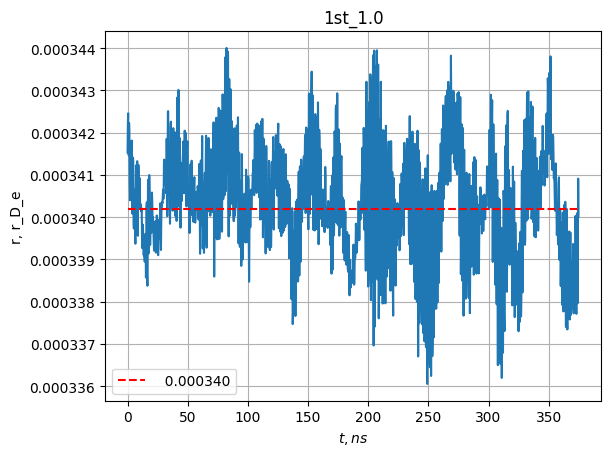

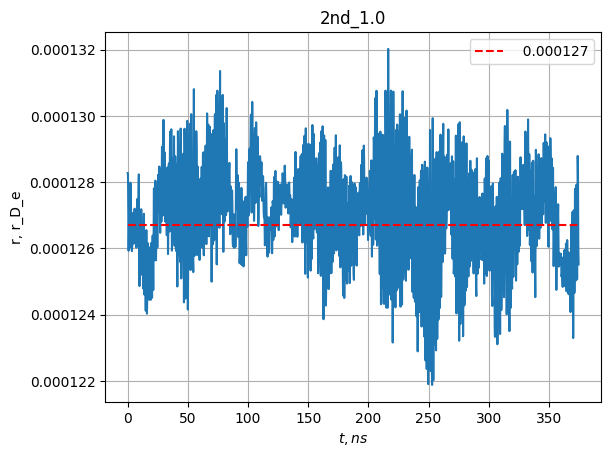

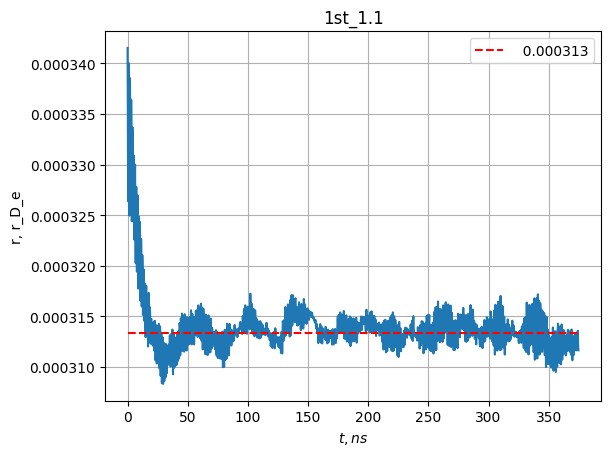

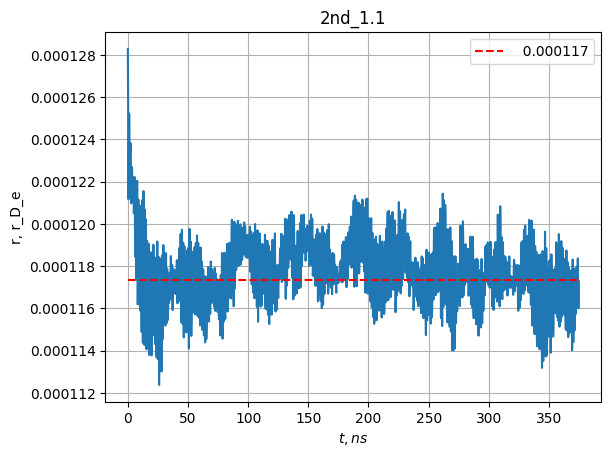

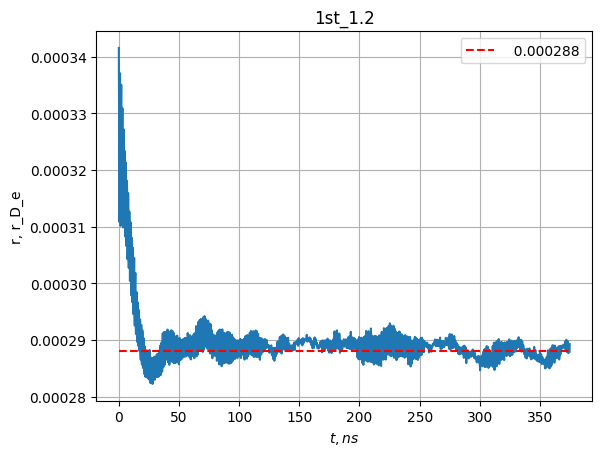

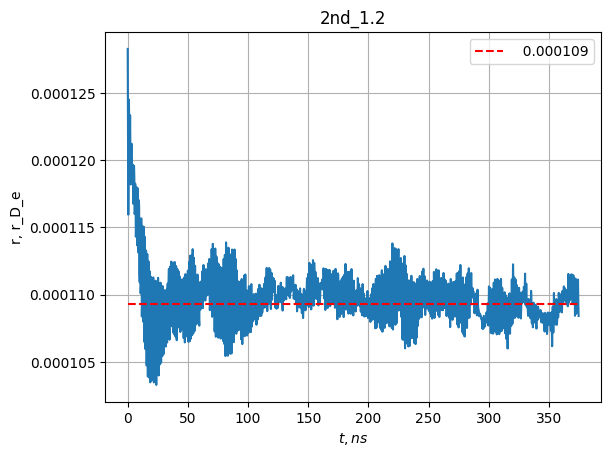

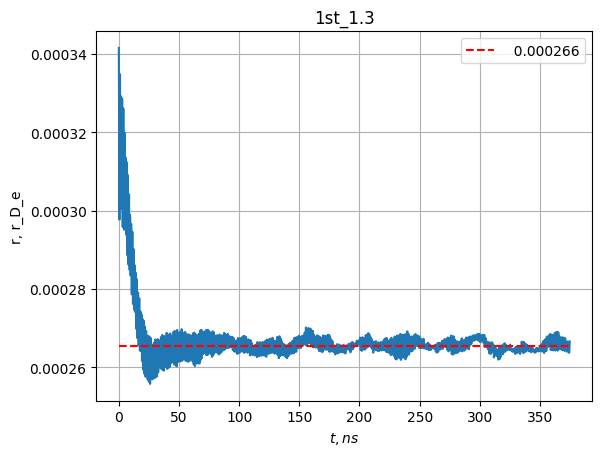

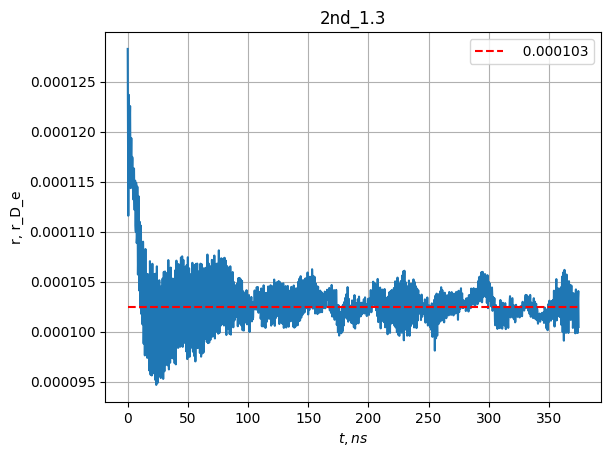

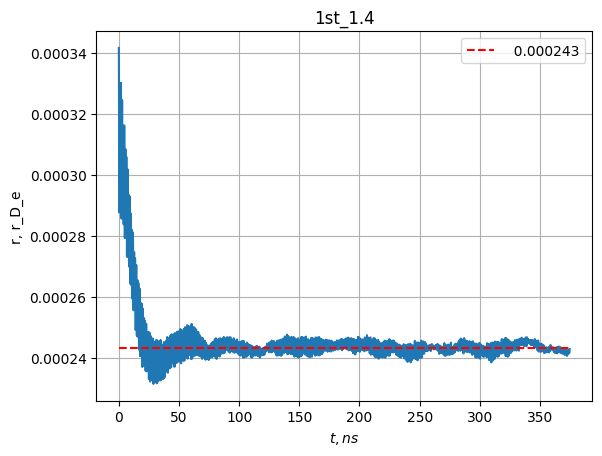

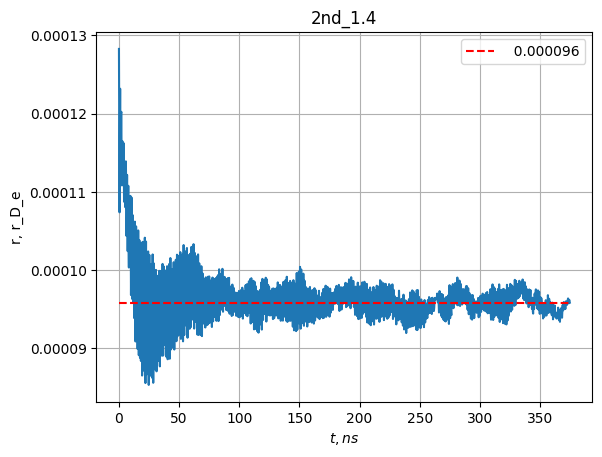

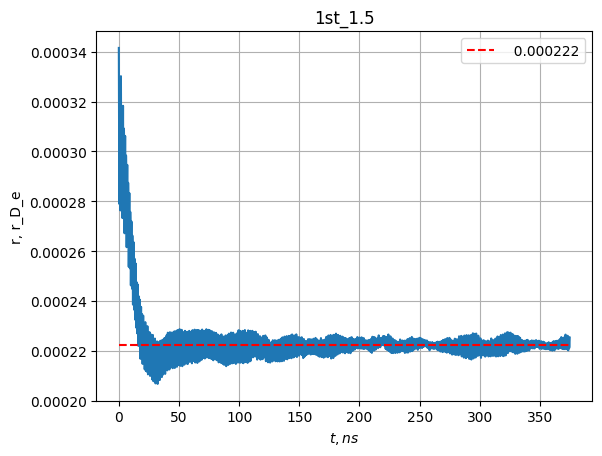

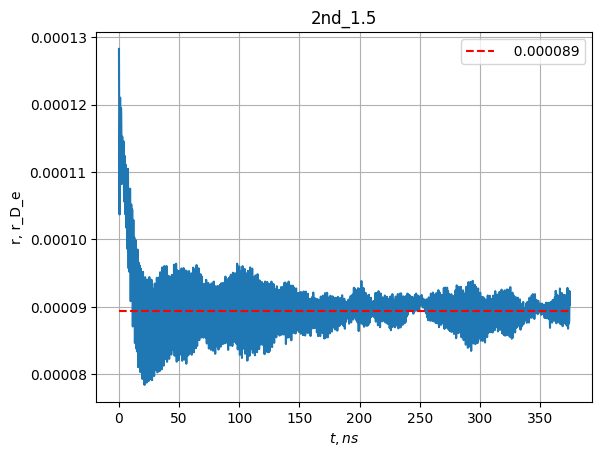

In [33]:
rs1 = []
rs2 = []
traps = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

for i in traps:
    data = np.genfromtxt(f"../data/traps/data_{i}.txt", delimiter="\t")

    rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
    rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))
    zs_1 = data[:, 3]
    vzs_1 = data[:, 6]

    vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
    vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))
    zs_2 = data[:, 9]
    vzs_2 = data[:, 12]

    t = (data[:, 0]) / 2.0 * 50.0
    t_min = np.min(t)
    t_max = np.max(t)

    k_B = 1.380649e-23  # Boltzmann constant (J/K)
    m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
    P = 0.25 * 18.131842  # Pressure (Pascal)
    r_D_e = 0.0016622715189364113

    rs1 += [display_with_mean(t, rs_1, f"1st_{i}", "r, r_D_e")]
    rs2 += [display_with_mean(t, rs_2, f"2nd_{i}", "r, r_D_e")]
    # display_with_mean(t, vs_1, "1st", "v, m/s")
    # display_with_mean(t, vs_2, "2nd", "v, m/s")

    # display_with_mean(t, zs_1, "1st", "r, r_D_e")
    # display_with_mean(t, zs_2, "2nd", "r, r_D_e")
    # display_with_mean(t, vzs_1, "1st", "v, m/s")
    # display_with_mean(t, vzs_2, "2nd", "v, m/s")

rs1 = np.array(rs1)
rs2 = np.array(rs2)

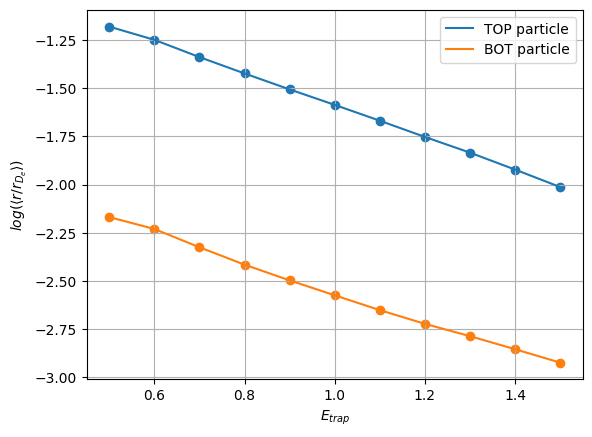

In [36]:
plt.figure(dpi=100)
plt.xlabel(r"$E_{trap}$")
plt.ylabel(r"$log(\left<r / r_{D_e}\right>)$")
plt.grid()
plt.plot(traps, np.log(rs1 / r_D_e), "-", label="TOP particle")
plt.plot(traps, np.log(rs2 / r_D_e), "-", label="BOT particle")
plt.scatter(
    traps,
    np.log(rs1 / r_D_e),
)
plt.scatter(
    traps,
    np.log(rs2 / r_D_e),
)
plt.legend(loc="best")
plt.show()

In [37]:
slope_1, _, _, _, _ = linregress(traps, np.log(rs1 / r_D_e))
slope_2, _, _, _, _ = linregress(traps, np.log(rs2 / r_D_e))

print(slope_1)
print(slope_2)

-0.8326203609156494
-0.7654024975555681
